In [1]:
import torch
import torchvision


import  torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available()  else  "cpu")

print(device)

cuda


In [3]:
from torchvision.datasets import ImageFolder

In [4]:
TRAIN_DIR = r"D:\industrial_defect_detection\datasets\archive\casting_data\casting_data\train"

TEST_DIR = r"D:\industrial_defect_detection\datasets\archive\casting_data\casting_data\test"

In [5]:
train_tfms = transforms.Compose([transforms.Resize((64, 64)),                     
    transforms.RandomAffine(degrees=40, shear=10, scale=(0.9, 1.1)),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])

test_tfms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [6]:
train_dataset =ImageFolder(root=TRAIN_DIR, transform=train_tfms)

test_dataset = ImageFolder(root=TEST_DIR, transform=test_tfms)

In [7]:
print(len(train_dataset))

6633


In [8]:
print(len(test_dataset))

715


In [9]:
from torch.utils.data import DataLoader

In [10]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True , num_workers=0)

test_loader = DataLoader(test_dataset , batch_size=32 , shuffle=False , num_workers=0)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
image , label = train_dataset[0]

In [13]:
image.shape

torch.Size([3, 64, 64])

In [14]:
image

tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]])

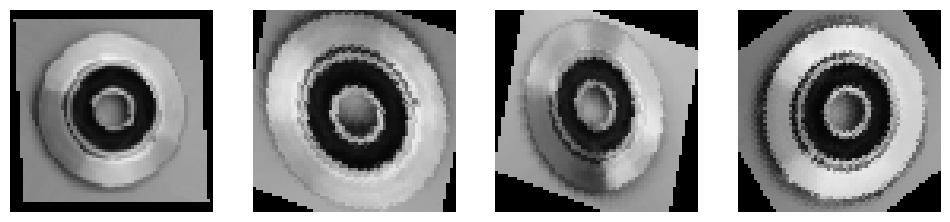

In [15]:
fig , axes = plt.subplots(1,4  , figsize=(12,4))

for i in range(4):
    images , labels = train_dataset[i]
    img = images/2 +0.5
    img = img.permute(1,2,0).numpy()
    
    axes[i].imshow(img)
    axes[i].axis('off')

plt.show()   

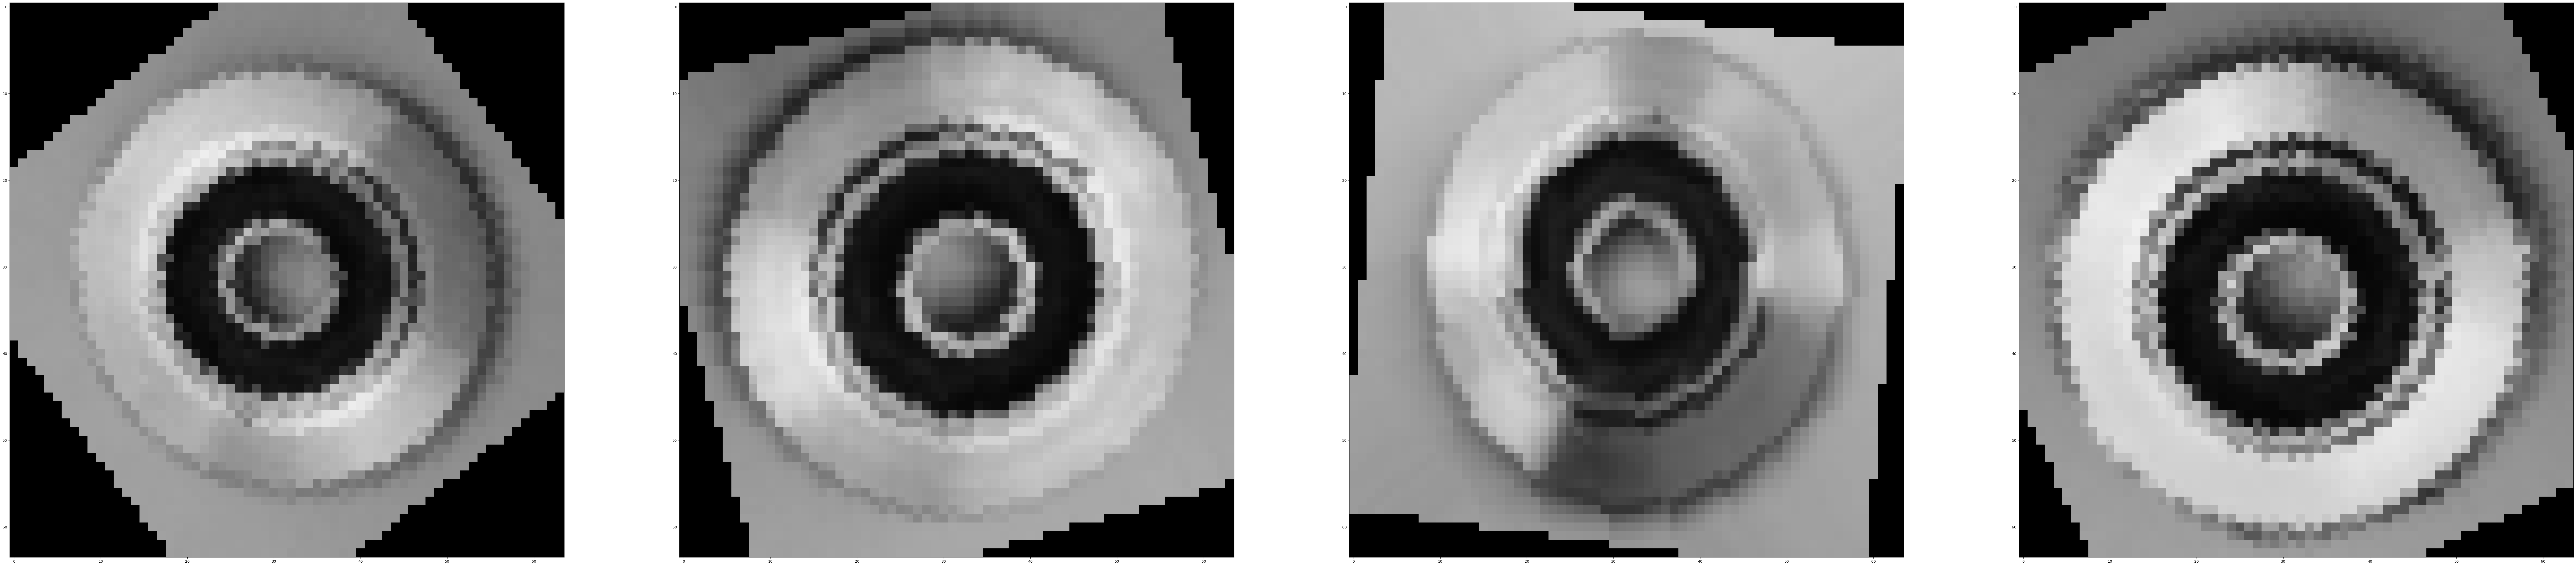

In [16]:
plt.figure(figsize=(128,128))

for i in range(4):
    plt.subplot(4,4  , i+1)
    images , labels = train_dataset[i]
    img = images/2 +0.5
    img = img.permute(1,2,0).numpy()
    plt.imshow(img)

In [17]:
train_dataset.class_to_idx

{'def_front': 0, 'ok_front': 1}

In [18]:
class_names = ['defective',  'ok'] if train_dataset.class_to_idx.get('def_front')==0 else ['ok' , 'defective']


In [19]:
class_names

['defective', 'ok']

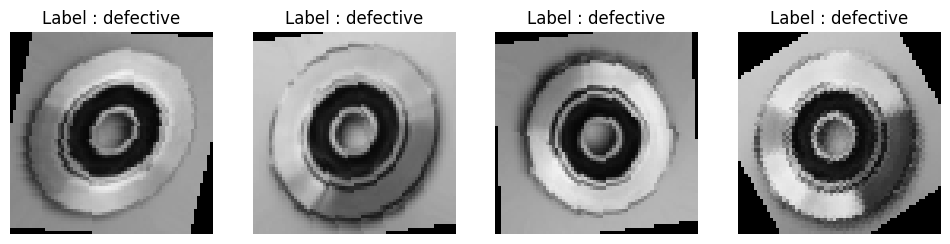

In [20]:
fig , axes = plt.subplots(1,4  , figsize=(12,4))



for i in range(4):
    images , labels = train_dataset[i*150]
    img = images/2 +0.5
    img = img.permute(1,2,0).numpy()
    
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Label : {class_names[labels]}')

plt.show()   

In [21]:
iterdata = iter(train_loader)

imagee , labelee = next(iterdata)

In [22]:
imagee.shape

torch.Size([32, 3, 64, 64])

In [23]:
class SE_block(nn.Module):
    def __init__(self , channels , reduction=4):
        super().__init__()

        self.fc1 = nn.Linear(channels , channels//reduction , bias=False)
        self.fc2 = nn.Linear(channels//reduction , channels , bias=False)


    def forward(self , x):
        b , c , h , w = x.shape

        s = x.mean(dim=(2,3))

        s = F.relu(self.fc1(s))

        s = torch.sigmoid(self.fc2(s))

        s = s.view(b , c , 1,1)

        return x*s
        
        

In [24]:
class Swish(nn.Module):
    def forward(self,x):
        return x* torch.sigmoid(x)

In [25]:
class MConv(nn.Module):
    def __init__(self , in_ch , out_ch , stride=1 , expand=6):
        super().__init__()

        hidden = in_ch  * expand
        self.use_kip = (stride==1 and in_ch==out_ch)


        self.expand = nn.Conv2d(in_ch , hidden , 1 , stride=stride , bias=False)
        self.bn1 = nn.BatchNorm2d(hidden)

        self.depthwise = nn.Conv2d(hidden , hidden , kernel_size=3 , stride=stride, padding=1 , bias=False)
        self.bn2 = nn.BatchNorm2d(hidden)

        self.se = SE_block(hidden)
        self.project = nn.Conv2d(hidden , out_ch ,1 , bias=False)
        self.bn3 = nn.BatchNorm2d(out_ch)

        self.act = Swish()

    def forward(self, x):
        inputs = x


        x = self.act(self.bn1(self.expand(x)))

        x = self.act(self.bn2(self.depthwise(x)))

        x = self.se(x)

        x = self.bn3(self.project(x))

        if self.use_kip:
            x = x + inputs

        return x    
        
         

In [26]:
class EfficientNet(nn.Module):
    def __init__(self, num_class=10):
        super().__init__()


        self.stem = nn.Conv2d(3 , 32 , 3 ,stride=2 , padding=1)


        self.block1 = MConv(32 , 16 , stride=1)

        self.block2 = MConv(16,24 , stride=2)

        self.block3 = MConv(24,40 , stride=2)

        self.block4 = MConv(40,80 , stride=2)

        self.block5 = MConv(80,112 , stride=1)

        self.block6 = MConv(112,192 , stride=2)

        self.block7 = MConv(192 , 320 , stride=1)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(320 , 1)



    def forward(self ,x ):
        x = self.stem(x)


        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.block4(x)

        x = self.block5(x)

        x = self.block6(x)

        x = self.block7(x)


        x = self.pool(x)
        x = x.view(x.size(0) , -1)

        return self.fc(x)


        

In [27]:
model = EfficientNet()

print(model)

EfficientNet(
  (stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (block1): MConv(
    (expand): Conv2d(32, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (depthwise): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (se): SE_block(
      (fc1): Linear(in_features=192, out_features=48, bias=False)
      (fc2): Linear(in_features=48, out_features=192, bias=False)
    )
    (project): Conv2d(192, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): Swish()
  )
  (block2): MConv(
    (expand): Conv2d(16, 96, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [28]:
model = EfficientNet().to(device)

In [29]:
loss_func = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters() , lr=0.001)

In [30]:
epochs = 5

for epoch in range(epochs):
    print(f'Strating Epoch :  {epoch+1}')

    model.train()
    runing_loss = 0.0

for images , labels in train_loader:
    images,labels = images , labels
    images = images.to(device)
    labels = labels.to(device)
    labels = labels.float().unsqueeze(1)

    optimizer.zero_grad()


    output = model(images)
    loss = loss_func(output ,labels)
    loss.backward()
    optimizer.step()

    runing_loss+=loss.item()
    

    

Strating Epoch :  1
Strating Epoch :  2
Strating Epoch :  3
Strating Epoch :  4
Strating Epoch :  5


In [31]:
correct = 0 
total = 0

model.eval()
with torch.no_grad():
    for images ,labels in test_loader:
        images ,labels = images , labels
        images=images.to(device)
        labels = labels.to(device)


        output = model(images)

        prob = torch.sigmoid(output)
        predicted = (prob>0.5).int()
        total+=labels.size(0)
        labelsss = labels.to(device).int().unsqueeze(1)
        correct+=(predicted==labelsss).sum().item()


        accuracy = 100*correct / total


        print(f'Accyracy  :  {accuracy:}')
        

Accyracy  :  87.5
Accyracy  :  84.375
Accyracy  :  83.33333333333333
Accyracy  :  81.25
Accyracy  :  82.5
Accyracy  :  82.8125
Accyracy  :  80.80357142857143
Accyracy  :  80.078125
Accyracy  :  80.55555555555556
Accyracy  :  79.6875
Accyracy  :  78.97727272727273
Accyracy  :  78.64583333333333
Accyracy  :  78.60576923076923
Accyracy  :  77.90178571428571
Accyracy  :  78.54166666666667
Accyracy  :  77.9296875
Accyracy  :  78.49264705882354
Accyracy  :  79.51388888888889
Accyracy  :  79.4407894736842
Accyracy  :  79.375
Accyracy  :  79.61309523809524
Accyracy  :  79.9715909090909
Accyracy  :  80.0


In [32]:


correct_imgs = []
wrong_images = []


correct_labels = []
wrong_labels = []

correct_preds = []
wrong_preds = []

model.eval()
with torch.no_grad():
    for images ,labels in test_loader:
        images ,labels = images , labels
        images=images.to(device)
        labelsz = labels.to(device)


        output = model(images)

        prob = torch.sigmoid(output)
        predicted = (prob>0.5).int()
        labelz = labels.to(device).int().unsqueeze(1)
        for i in range(len(images)):

            if predicted[i]==labelz[i]:

                   correct_imgs.append(images[i].cpu())
                   correct_labels.append(labels[i].item())
                   correct_preds.append(predicted[i].item())


        else:   

                wrong_images.append(images[i].cpu())
                wrong_labels.append(labels[i].item())
                wrong_preds.append(predicted[i].item())

        
        
    

  
    

In [33]:
wrong_preds

[0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [34]:
correct_preds

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def show_images(images , labels , preds , title):
    fig , axes = plt.subplots(1,6 , figsize=(12,3))




    for i in range(6):
        img = images[i] / 2 +0.5
        npimg = img.numpy().transpose(1,2,0)


        axes[i].imshow(npimg)
        axes[i].set_title(f'T:{labels[i]}')
        axes[i].axis('off')

    plt.show() 

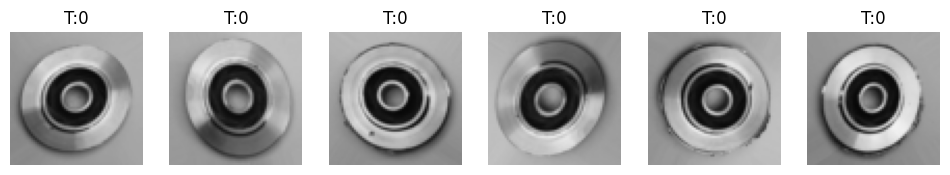

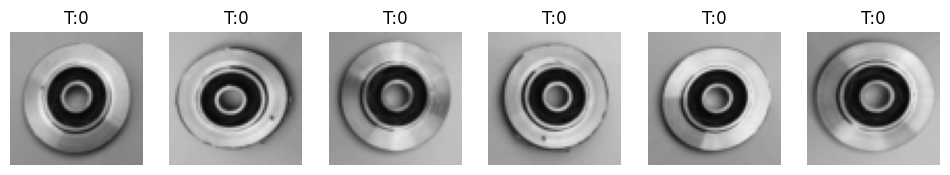

In [37]:
show_images(correct_imgs , correct_labels , correct_preds , 'Correct Precition' )

show_images(wrong_images , wrong_labels , wrong_preds , 'Wrong Prection')

In [39]:
wrong_images[0].shape

torch.Size([3, 64, 64])

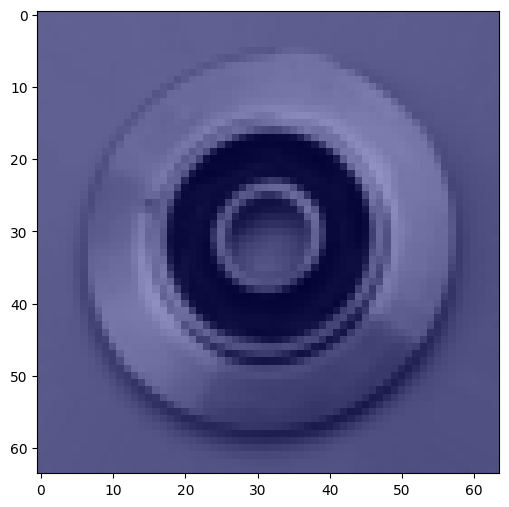

In [40]:
activation = {}
gradieant = {}


def forward_hook(module , input , output):
    activation['value'] = output

def backward_hook(module , grad_input , grad_output):
    gradieant['value'] = grad_output[0]


model.block6.register_forward_hook(forward_hook)
model.block6.register_full_backward_hook(backward_hook)



model.eval()

img = wrong_images[0].unsqueeze(0).to(device)
output = model(img)


pred_class = output.argmax(dim=1)


model.zero_grad()
output[0 , pred_class].backward()


grads = gradieant['value'][0]
acts = activation['value'][0]

weights = grads.mean(dim=(1,2))

cam = torch.zeros(acts.shape[1:], device=device)

for i , w in enumerate(weights):
    cam+= w * acts[i]

cam = cam.cpu().detach()
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

import cv2


img_np = img.squeeze(0).cpu().detach().numpy().transpose(1,2,0)
img_np = img_np / 2 + 0.5
img_np = np.clip(img_np , 0 ,1)

height , width ,_= img_np.shape

cam_resized = cv2.resize(cam.numpy(), (width ,height))

plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.imshow(cam_resized , cmap = 'jet' , alpha=0.4 )
plt.show()


In [41]:
print(grads.shape)

torch.Size([192, 1, 1])


In [42]:
print(cam.max().item())

0.0


In [43]:
print(cam==0).all().item()

tensor([[True]])


AttributeError: 'NoneType' object has no attribute 'all'

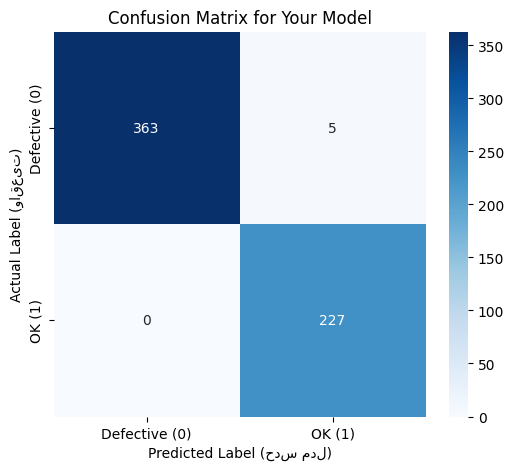

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ۱. ترکیب کردن لِیبل‌های واقعی (درست‌ها + غلط‌ها)
# متغیرهای labels شامل لِیبل‌های واقعی دیتای تو هستند
all_true = correct_labels + wrong_labels

# ۲. ترکیب کردن پیش‌بینی‌های مدل (درست‌ها + غلط‌ها)
# متغیرهای preds شامل حدس‌های مدل تو هستند
all_pred = correct_preds + wrong_preds


# ۳. محاسبه ریاضی ماتریس اغتشاش بر اساس دیتای واقعی تو
cm = confusion_matrix(all_true, all_pred)

# ۴. نام‌گذاری کلاس‌ها (۰ برای خراب و ۱ برای سالم)
class_names = ['Defective (0)', 'OK (1)']

# ۵. رسم و رنگ‌آمیزی نمودار با Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

# ۶. قشنگ‌سازی و زدن برچسب‌ها
plt.title('Confusion Matrix for Your Model')
plt.ylabel('Actual Label (واقعیت)')
plt.xlabel('Predicted Label (حدس مدل)')
plt.show()

